# kitscenes — Calibration & Multi-Sensor Demo

This notebook demonstrates calibration data and multi-sensor integration:

1. Calibration overview — all cameras & lidars
2. Sensor layout — plot sensor positions from extrinsics
3. Multi-LiDAR point cloud — merge sweeps from all lidars
4. Camera + LiDAR overlay — project 3D points onto a camera image
5. Compensated radar BEV — ego-motion-compensated radar detections overlaid with lidar
6. Timestamp synchronization check
7. Ego-pose trajectory from `poses.txt` (TUM format)
8. Map-to-camera projection — lane boundaries overlaid on camera images

In [11]:
# -- Configuration --------------------------------------------------------
DATASET_ROOT = "/data/kitscenes"  # absolute path to the dataset root
SCENE_ID = "c34c778f-ad8c-0aa9-7e1a-c86a73f887c7"  # sample val scene
FRAME_IDX = 50   # frame used for single-frame visualizations

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from kitscenes import KITScenesDataset
from kitscenes.constants import CAMERA_NAMES, LIDAR_NAMES, RADAR_NAMES
from kitscenes.map_api import load_scene_map

ds = KITScenesDataset(root=DATASET_ROOT)
if SCENE_ID not in ds.scene_ids:
    raise ValueError(f"Scene {SCENE_ID!r} not found under {DATASET_ROOT}")

scene = ds.get_scene(SCENE_ID)
loader = ds.get_sensor_loader(SCENE_ID)

print(f"Scene:   {scene.scene_id}")
print(f"Frames:  {scene.metadata.num_frames}")
print(f"Cameras: {len(loader.get_camera_names())}")
print(f"LiDARs:  {len(loader.get_lidar_names())}")
print(f"Radars:  {len(loader.get_radar_names())}")

Scene:   c34c778f-ad8c-0aa9-7e1a-c86a73f887c7
Frames:  220
Cameras: 9
LiDARs:  7
Radars:  3


## 1. Calibration Overview

Print intrinsic parameters and image sizes for all cameras, and extrinsic matrices for all lidars.

In [13]:
# Camera calibrations
print(f"{'Camera':<35} {'Focal (px)':>10} {'CU':>8} {'CV':>8} {'W':>6} {'H':>6}")
print("-" * 80)

calibrations = {}
for cam_name in loader.get_camera_names():
    calib = loader.get_camera_calibration(cam_name)
    calibrations[cam_name] = calib
    f = calib.intrinsic[0, 0]
    cu = calib.intrinsic[0, 2]
    cv = calib.intrinsic[1, 2]
    sz = calib.image_size
    w_str = str(sz[0]) if sz else "N/A"
    h_str = str(sz[1]) if sz else "N/A"
    print(f"{cam_name:<35} {f:>10.1f} {cu:>8.1f} {cv:>8.1f} {w_str:>6} {h_str:>6}")

Camera                              Focal (px)       CU       CV      W      H
--------------------------------------------------------------------------------
camera_base_front_center                3022.0   2924.0   1545.0   5856   3104
camera_base_front_left_rect             1843.0   1139.0   1754.0   2272   3488
camera_base_front_right_rect            1843.0   1139.0   1754.0   2272   3488
camera_ring_front                       1841.0   1740.0   1139.0   3504   2272
camera_ring_front_left                  1844.0   1764.0   1131.0   3504   2272
camera_ring_front_right                 1845.0   1749.0   1138.0   3504   2272
camera_ring_rear                        1845.0   1765.0   1135.0   3504   2272
camera_ring_rear_left                   1843.0   1769.0   1136.0   3504   2272
camera_ring_rear_right                  1847.0   1756.0   1148.0   3504   2272


In [14]:
# LiDAR extrinsics
lidar_extrinsics = {}
for lid_name in loader.get_lidar_names():
    ext = loader.get_lidar_extrinsic(lid_name)
    lidar_extrinsics[lid_name] = ext
    pos = ext[:3, 3]
    print(f"{lid_name:<25} position: ({pos[0]:+.3f}, {pos[1]:+.3f}, {pos[2]:+.3f}) m")

lidar_top                 position: (+0.000, +0.000, +0.000) m
lidar_front               position: (+0.400, +0.015, -0.500) m
lidar_left                position: (-0.016, +0.433, -0.499) m
lidar_right               position: (-0.003, -0.416, -0.479) m
lidar_rear                position: (-0.822, -0.015, -0.478) m
lidar_corner_left         position: (+0.395, +0.522, -0.393) m
lidar_corner_right        position: (+0.434, -0.537, -0.373) m


## 2. Sensor Layout — BEV of Sensor Positions

Plot the (x, y) position of each sensor extracted from the `T_to_reference` extrinsic matrix. This shows the physical arrangement on the vehicle.

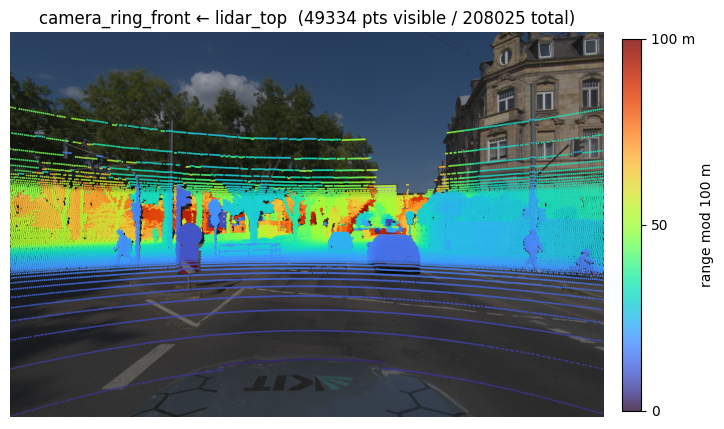

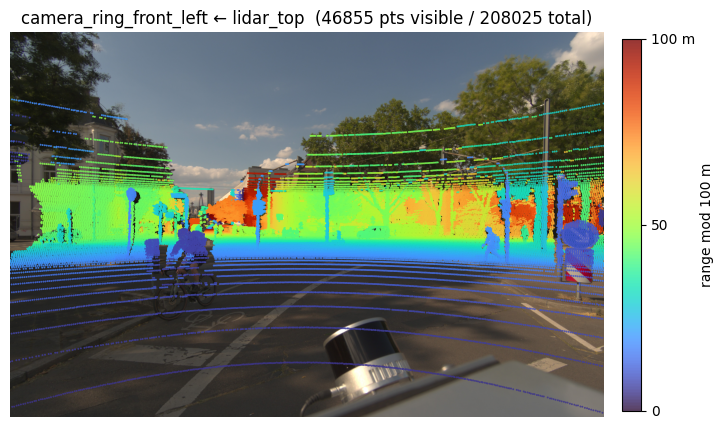

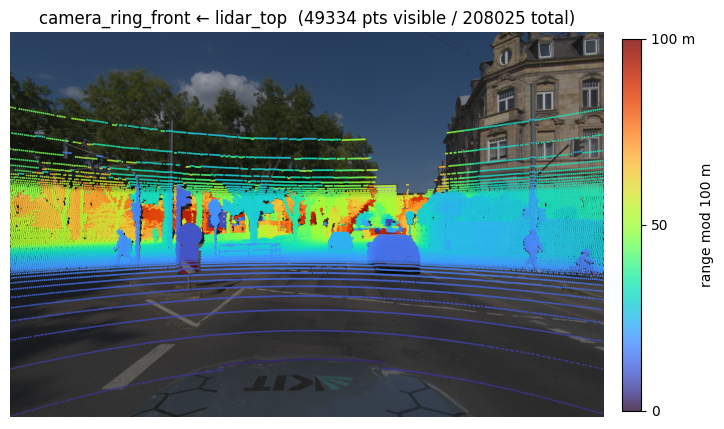

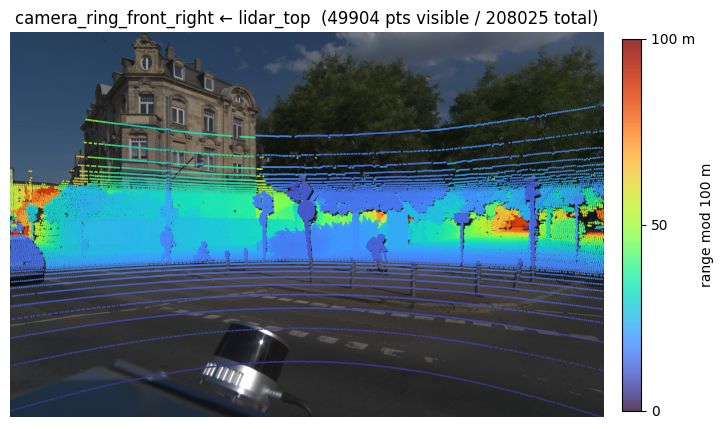

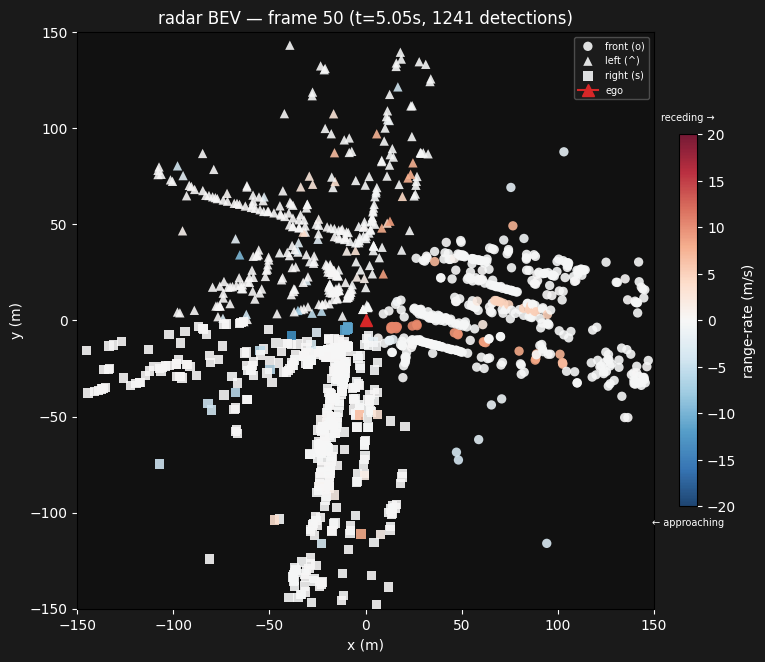

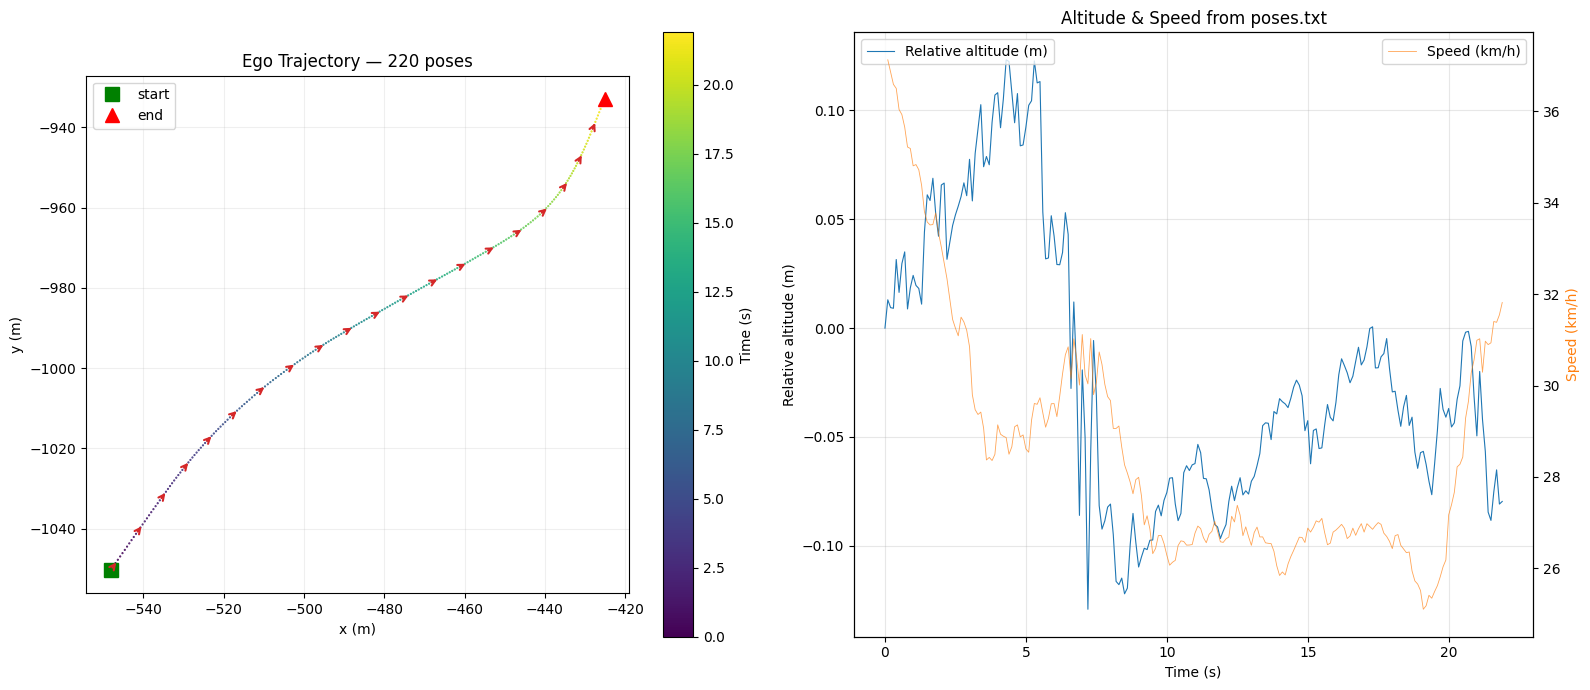

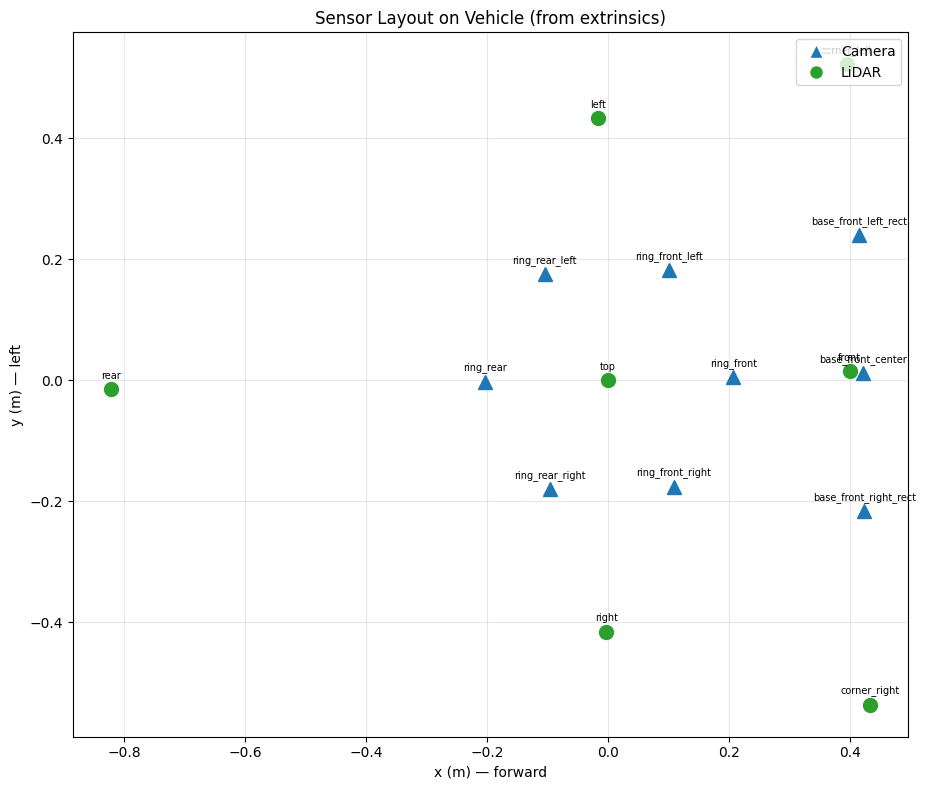

In [15]:
fig, ax = plt.subplots(figsize=(10, 8))
%matplotlib inline

# Cameras
for cam_name, calib in calibrations.items():
    pos = calib.extrinsic[:3, 3]
    short = cam_name.replace("camera_", "")
    ax.plot(pos[0], pos[1], "^", markersize=10, color="#1f77b4")
    ax.annotate(short, (pos[0], pos[1]), fontsize=7, ha="center", va="bottom",
                xytext=(0, 6), textcoords="offset points")

# LiDARs
for lid_name, ext in lidar_extrinsics.items():
    pos = ext[:3, 3]
    short = lid_name.replace("lidar_", "")
    ax.plot(pos[0], pos[1], "o", markersize=10, color="#2ca02c")
    ax.annotate(short, (pos[0], pos[1]), fontsize=7, ha="center", va="bottom",
                xytext=(0, 6), textcoords="offset points")

# Radars (no extrinsics in calib.json, so just note it)
ax.set_xlabel("x (m) — forward")
ax.set_ylabel("y (m) — left")
ax.set_title("Sensor Layout on Vehicle (from extrinsics)")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

# Legend
from matplotlib.lines import Line2D
legend_items = [
    Line2D([0], [0], marker="^", color="w", markerfacecolor="#1f77b4", markersize=10, label="Camera"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#2ca02c", markersize=10, label="LiDAR"),
]
ax.legend(handles=legend_items, loc="upper right")

plt.tight_layout()
plt.show()

## 3. Multi-LiDAR Point Cloud

Load sweeps from all 7 lidars at the same frame, transform into the reference frame using extrinsics, and display a merged BEV coloured by sensor.

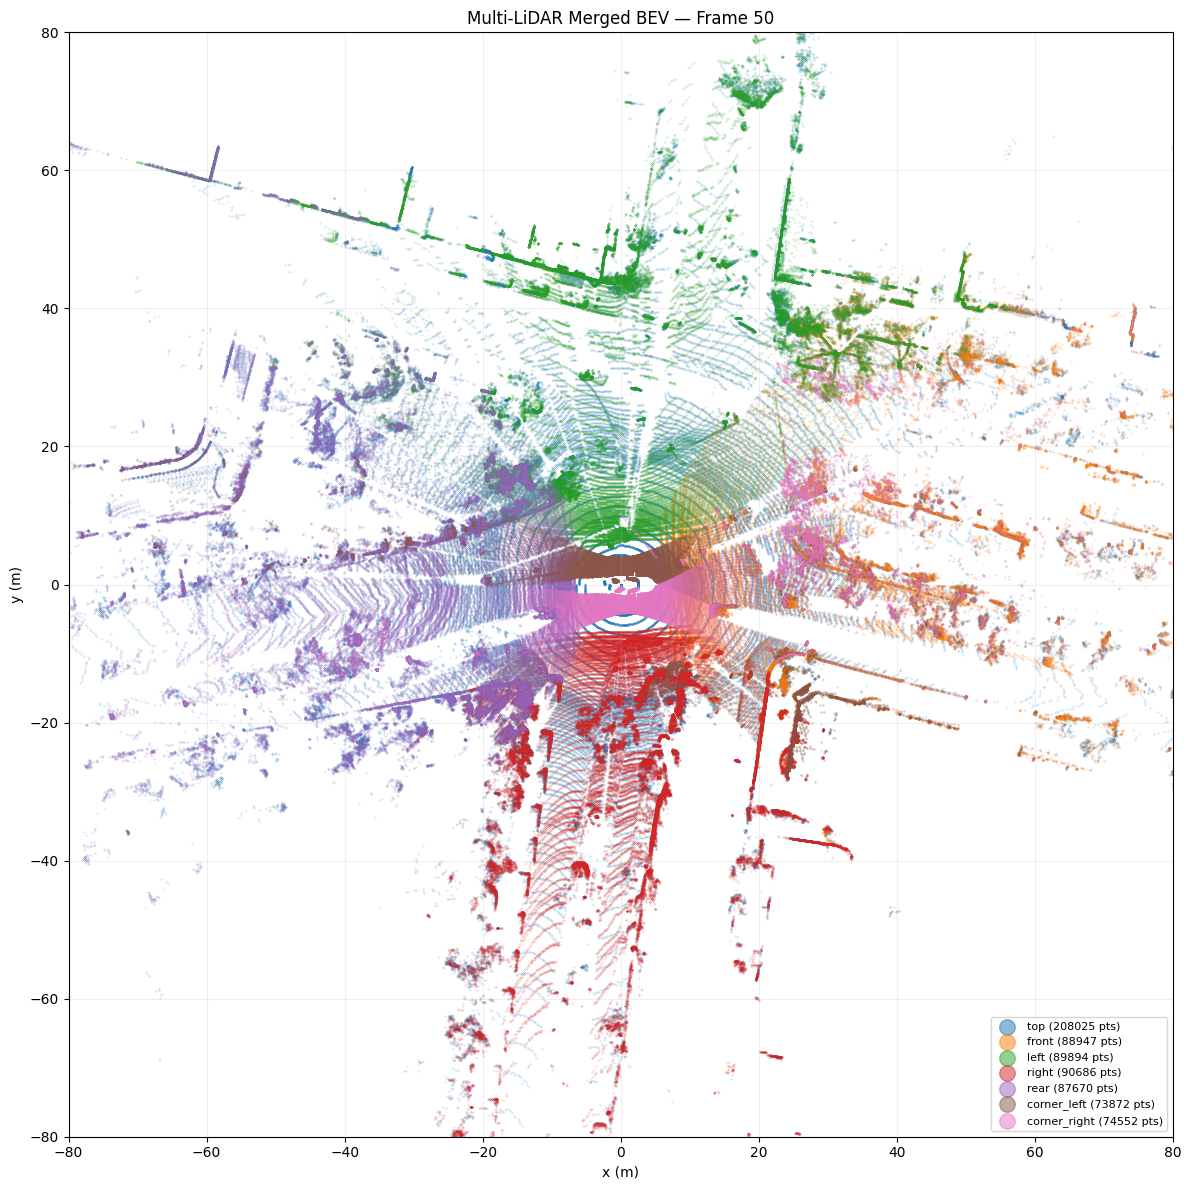

In [16]:
frame_idx = min(FRAME_IDX, scene.metadata.num_frames - 1)
colors_map = plt.cm.tab10(np.linspace(0, 1, 10))
%matplotlib inline

fig, ax = plt.subplots(figsize=(12, 12))

for i, lid_name in enumerate(loader.get_lidar_names()):
    try:
        sweep = loader.get_lidar_sweep(lid_name, frame_idx)
    except FileNotFoundError:
        print(f"  {lid_name}: frame {frame_idx} not found, skipping")
        continue

    pts = sweep.points
    # sweep.points is already in the reference frame (deskewed with sensor extrinsic)
    x = pts["x"].astype(np.float64)
    y = pts["y"].astype(np.float64)

    short = lid_name.replace("lidar_", "")
    ax.scatter(x, y, s=0.05, color=colors_map[i],
              alpha=0.5, label=f"{short} ({len(pts)} pts)")

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title(f"Multi-LiDAR Merged BEV — Frame {frame_idx}")
ax.set_aspect("equal")
ax.legend(markerscale=50, fontsize=8)
ax.set_xlim(-80, 80)
ax.set_ylim(-80, 80)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## 4. Camera + LiDAR Overlay

Use `render_lidar_on_camera` from `kitscenes.visualization` — it handles the calibration
pipeline (reference frame → camera frame → pixel projection) internally.

Deskewed: True


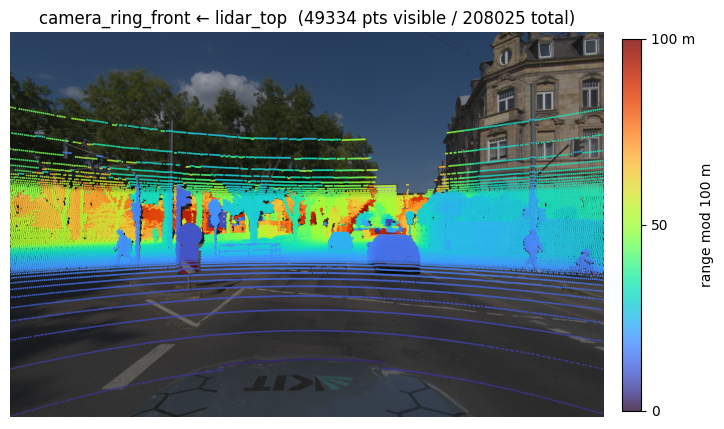

In [17]:
from kitscenes.visualization import render_lidar_on_camera
from kitscenes.frame import Frame
%matplotlib inline

# Build a Frame object — the viz functions operate on Frame, not raw loader calls
frame = Frame(
    scene_id=SCENE_ID,
    frame_idx=frame_idx,
    timestamp_ns=int(scene.timestamps_ns[frame_idx]),
    loader=loader,
    ego_poses=scene.ego_poses,
)

sweep = frame.lidar("lidar_top")
print(f"Deskewed: {sweep.deskewed}")

fig, ax = render_lidar_on_camera(frame, camera_name="camera_ring_front", lidar_name="lidar_top")
plt.show()

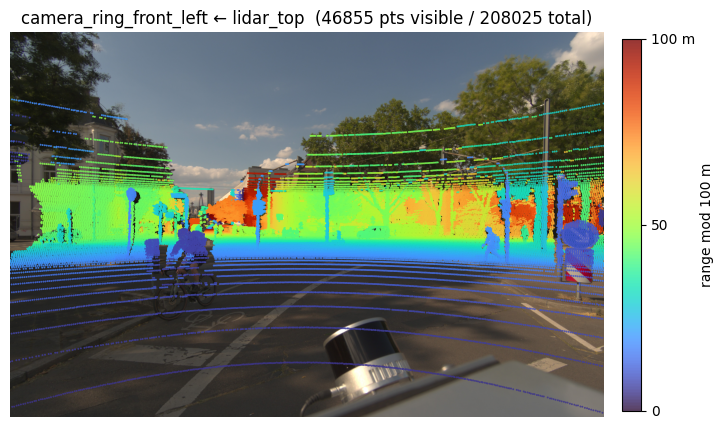

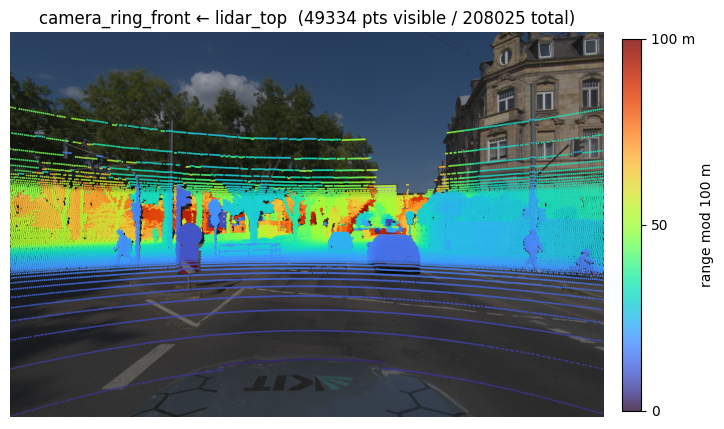

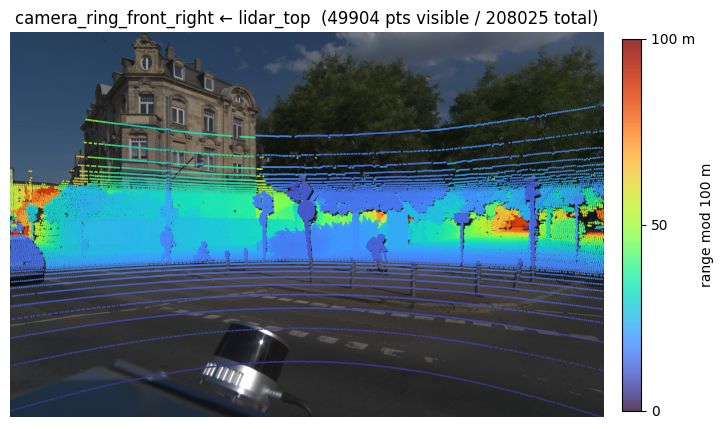

In [18]:
# Project lidar_top onto all three front cameras
%matplotlib inline

for cam in ["camera_ring_front_left", "camera_ring_front", "camera_ring_front_right"]:
    fig, ax = render_lidar_on_camera(frame, camera_name=cam, lidar_name="lidar_top")
    plt.show()

## 5. Compensated Radar BEV — Range-Rate Overlay

Use `render_radar_bev` from `kitscenes.visualization`.  It renders one polar subplot
per radar sensor (sensor-local frame).  Once radar extrinsics are added to `calib.json`
it switches automatically to a shared Cartesian reference-frame BEV.

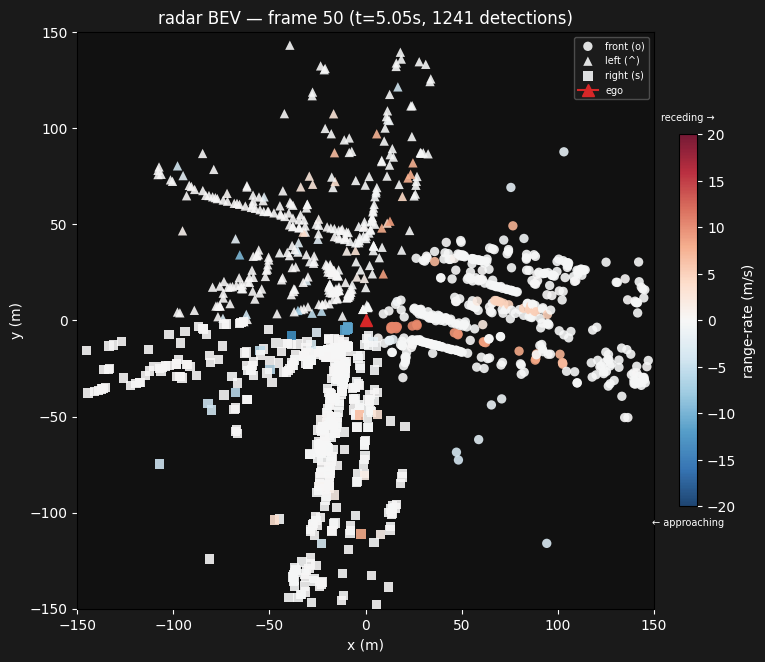

In [19]:
from kitscenes.visualization import render_radar_bev
%matplotlib inline

fig, axes = render_radar_bev(frame)
plt.show()

## 6. Ego-Pose Trajectory — `poses.txt` (TUM format)

Ego poses are loaded from the scene-root `poses.txt` file in TUM format: `timestamp tx ty tz qx qy qz qw`.

They are accessed via `scene.ego_poses` and plotted as a trajectory alongside altitude and speed.

Ego poses loaded: 220


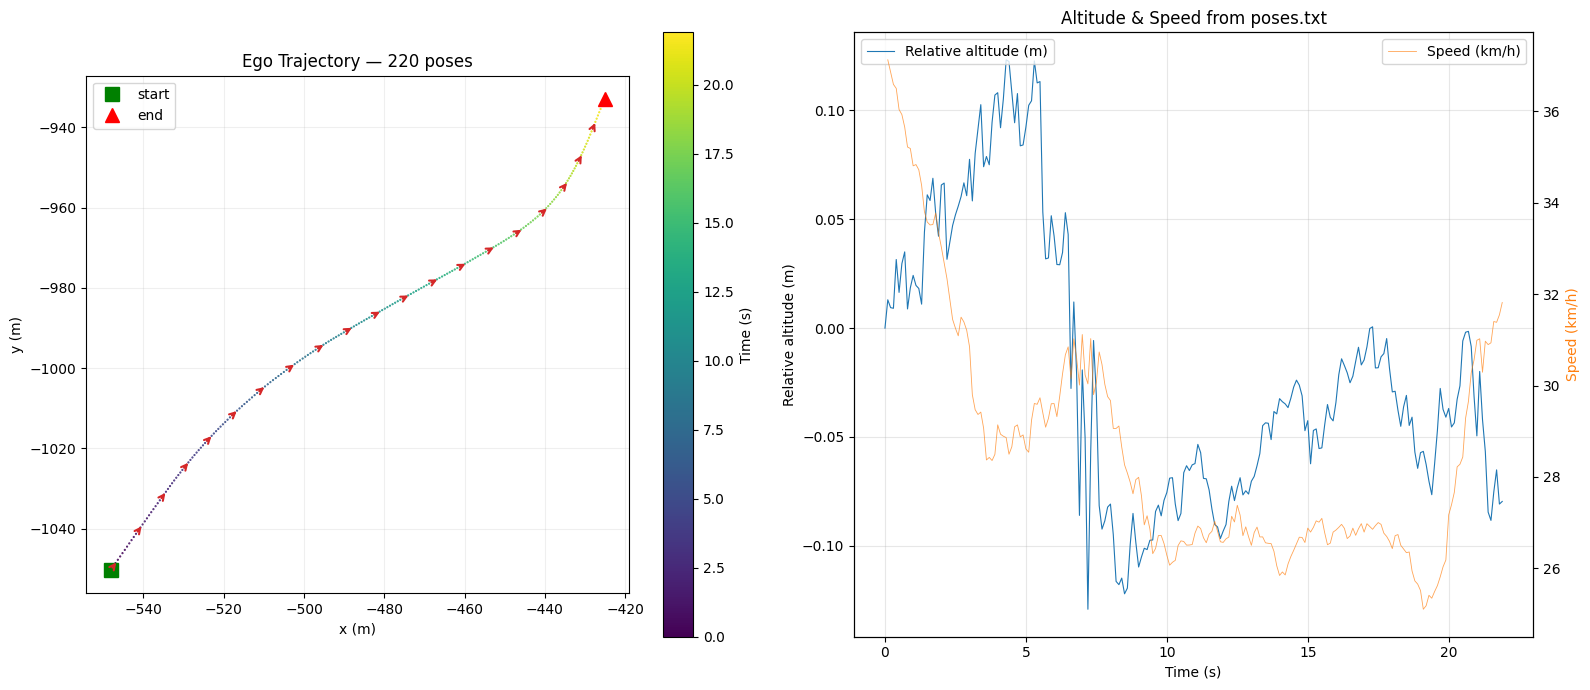

Trajectory length: 174 m
Mean speed: 28.6 km/h   Max: 37.1 km/h


In [20]:
ego_poses = scene.ego_poses
print(f"Ego poses loaded: {len(ego_poses)}")
%matplotlib inline

if ego_poses:
    ego_xy = np.array([ep.translation[:2] for ep in ego_poses])
    ego_z  = np.array([ep.translation[2]   for ep in ego_poses])
    ego_ts = np.array([ep.timestamp_ns      for ep in ego_poses])
    ego_t_s = (ego_ts - ego_ts[0]) / 1e9

    quats = np.array([ep.rotation for ep in ego_poses])  # qx, qy, qz, qw
    yaw = np.arctan2(
        2 * (quats[:, 3] * quats[:, 2] + quats[:, 0] * quats[:, 1]),
        1 - 2 * (quats[:, 1]**2 + quats[:, 2]**2),
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    ax = axes[0]
    sc = ax.scatter(ego_xy[:, 0], ego_xy[:, 1], s=0.3, c=ego_t_s, cmap="viridis")
    plt.colorbar(sc, ax=ax, label="Time (s)")
    ax.plot(*ego_xy[0], "gs", markersize=10, label="start")
    ax.plot(*ego_xy[-1], "r^", markersize=10, label="end")
    for i in range(0, len(ego_poses), max(1, len(ego_poses) // 20)):
        dx = 3.0 * np.cos(yaw[i])
        dy = 3.0 * np.sin(yaw[i])
        ax.annotate("", xy=(ego_xy[i, 0] + dx, ego_xy[i, 1] + dy),
                    xytext=(ego_xy[i, 0], ego_xy[i, 1]),
                    arrowprops=dict(arrowstyle="->", color="#d62728", lw=1.5))
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title(f"Ego Trajectory — {len(ego_poses)} poses")
    ax.set_aspect("equal")
    ax.legend()
    ax.grid(True, alpha=0.2)

    ax = axes[1]
    dt = np.diff(ego_t_s)
    dist = np.linalg.norm(np.diff(ego_xy, axis=0), axis=1)
    speed_kmh = (dist / np.maximum(dt, 1e-6)) * 3.6
    ax.plot(ego_t_s, ego_z - ego_z[0], linewidth=0.8, label="Relative altitude (m)")
    ax2 = ax.twinx()
    ax2.plot(ego_t_s[1:], speed_kmh, linewidth=0.6, color="#ff7f0e", alpha=0.7, label="Speed (km/h)")
    ax2.set_ylabel("Speed (km/h)", color="#ff7f0e")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Relative altitude (m)")
    ax.set_title("Altitude & Speed from poses.txt")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

    print(f"Trajectory length: {np.sum(dist):.0f} m")
    print(f"Mean speed: {np.mean(speed_kmh):.1f} km/h   Max: {np.max(speed_kmh):.1f} km/h")
else:
    print("No ego poses found — check that poses.txt exists in the scene directory.")